[2026-07-10 11:04:33] [info     ] 计算因子，区间：2019-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-10 11:05:31] [info     ] 读取因子库，区间：2019-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-10 11:05:33] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-10 11:06:21] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-10 11:06:25] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-10 11:06:31] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2019-01-02 至 2024-12-31
[2026-07-10 11:06:31] [info     ] ========== 数据检查 ==========
[2026-07-10 11:06:32] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2020-02-03~2020-03-31,0.0041
2024-01-15~2024-02-08,0.0156
2024-09-24~2024-10-08,0.0141

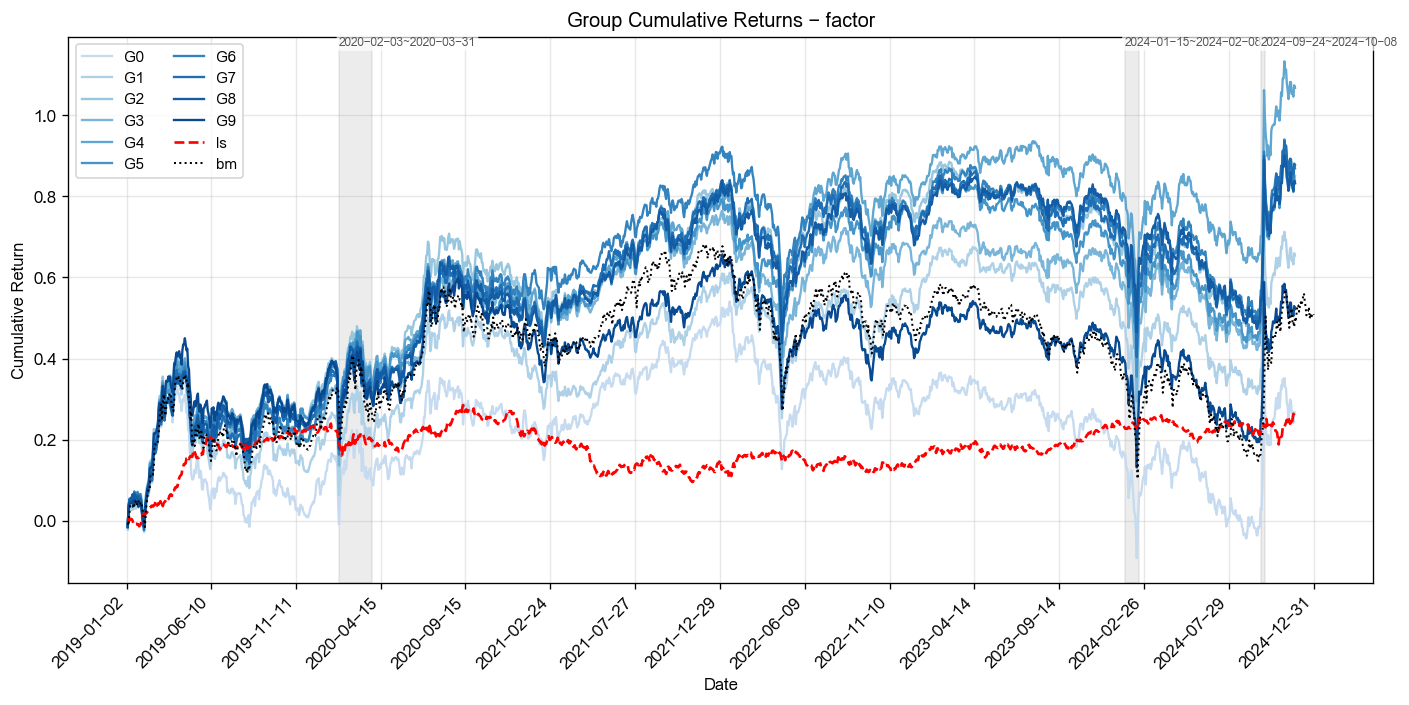
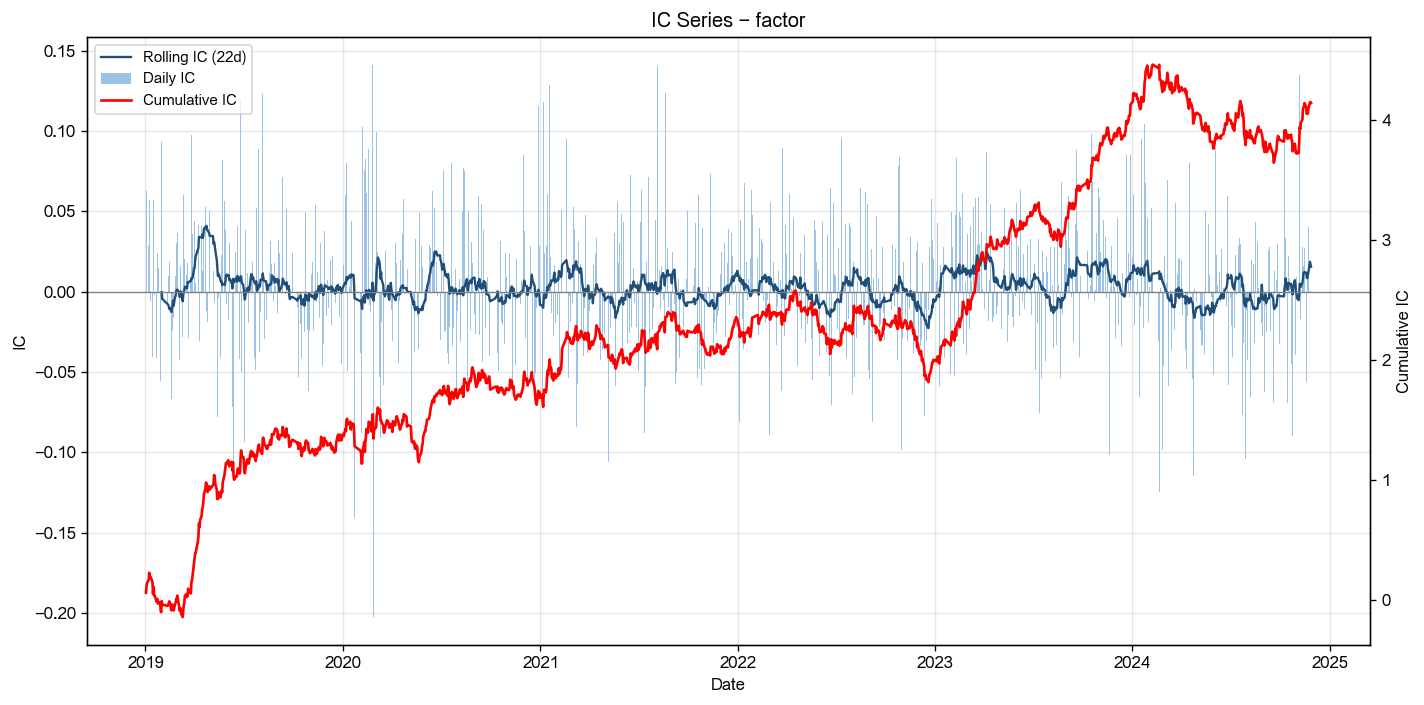
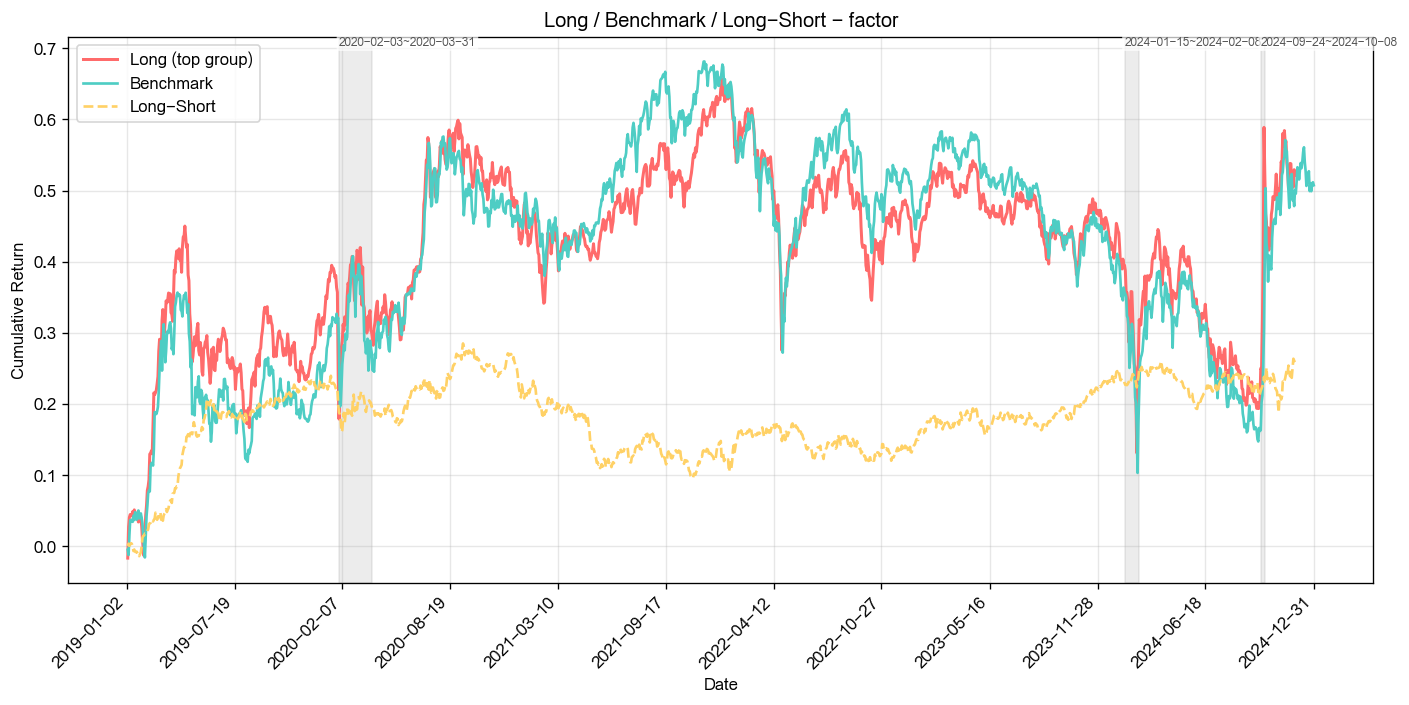
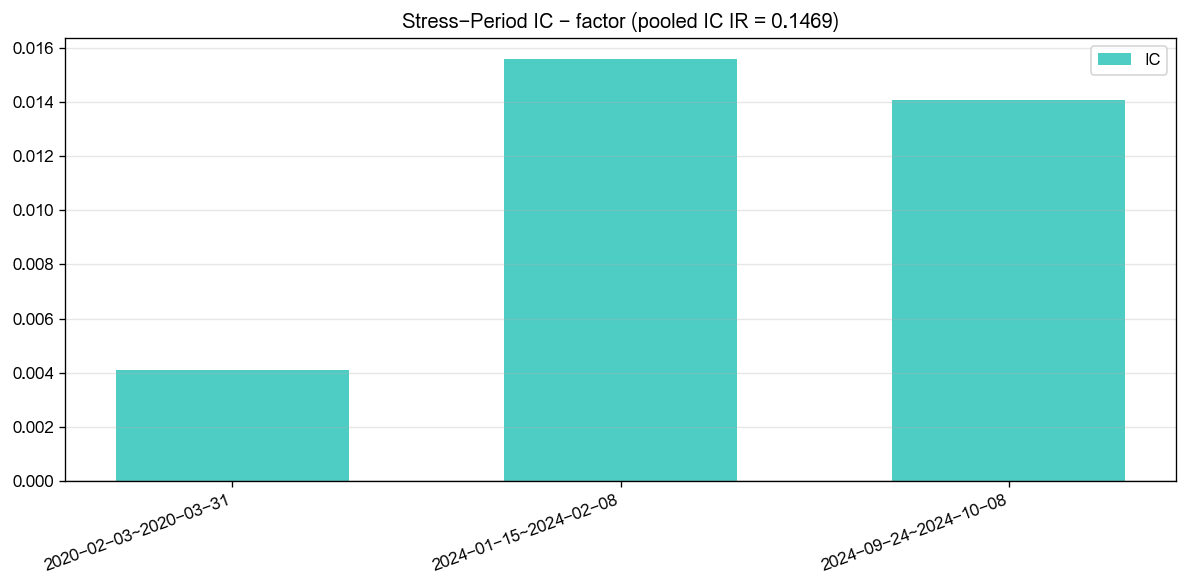
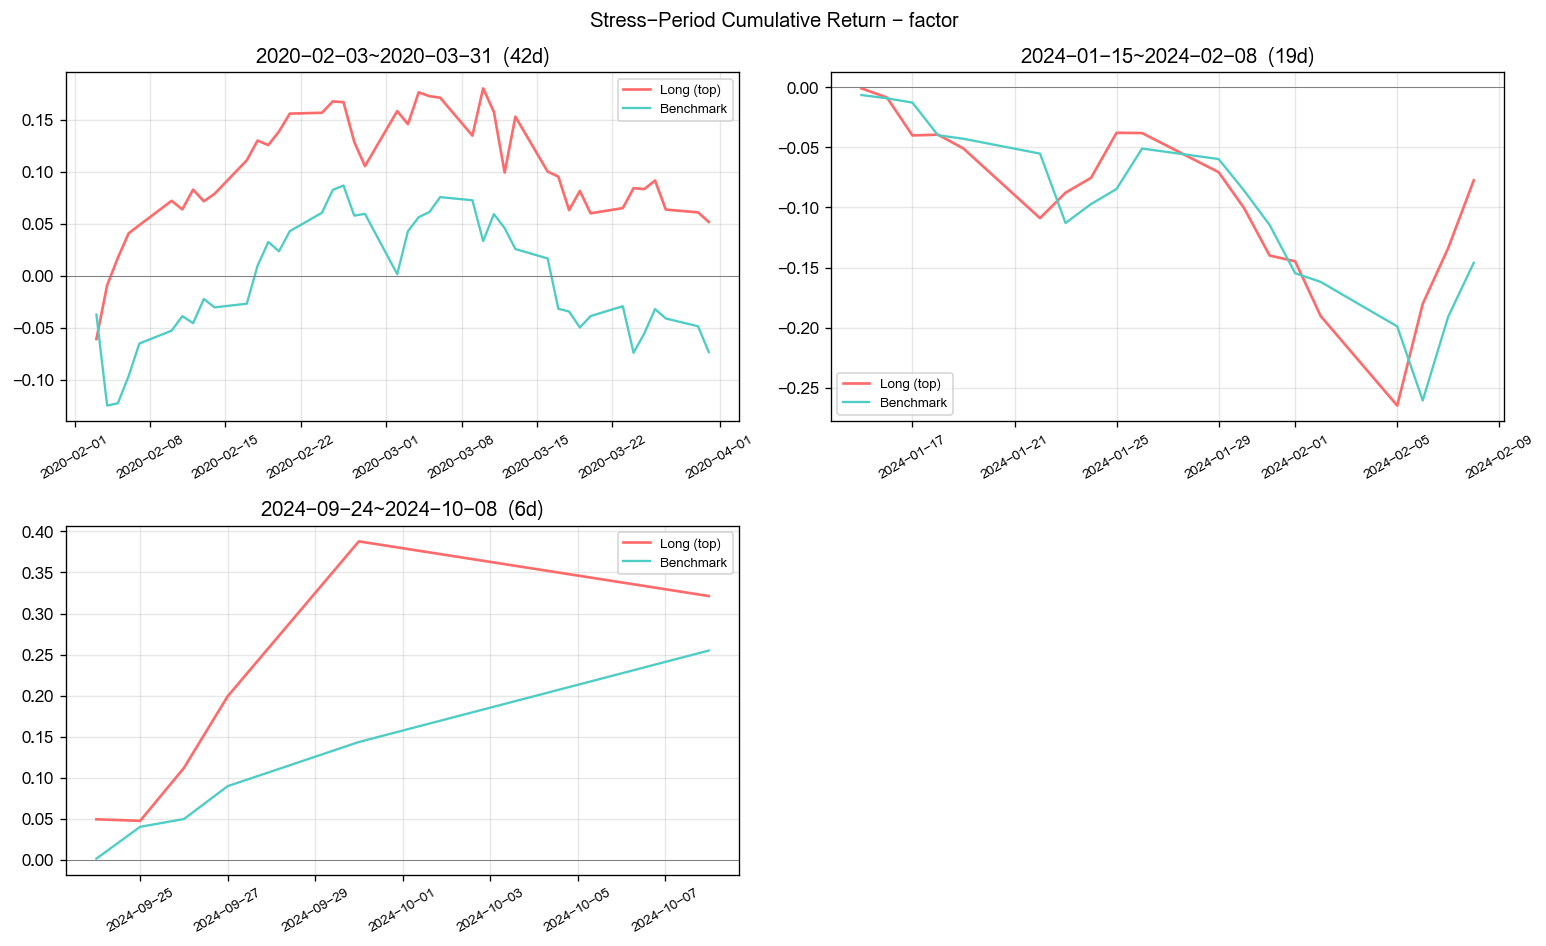

[2026-07-10 11:08:33] [info     ] ========== 因子池回归 ==========
[2026-07-10 11:08:36] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=2075 rows=2695583 start_date=2019-01-02
[2026-07-10 11:08:42] [info     ] 获取收益率数据, 耗时: 8.5991 秒
[2026-07-10 11:08:44] [info     ] 滚动 Elastic Net 拟合, 耗时: 2.4709 秒
[2026-07-10 11:08:44] [info     ] 统计 回归结果, 耗时: 0.0079 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,beta_000300SH_22,1.5432,0.0177,0.0114,0.9714
2,turn,1.4576,0.0266,0.0182,0.9429
3,cci_14,1.3882,0.0293,0.0211,0.9857
4,bias_20,1.3698,0.0298,0.0218,0.9714
5,momentum_5,1.3553,0.0180,0.0133,0.9571
6,list_days,1.3377,0.0105,0.0078,0.9714
7,net_active_buy_amount_main,1.2738,0.0169,0.0132,0.9286
8,macd_hist_12_26_9,1.2669,0.0077,0.0061,0.9857
9,volatility_5,1.2636,0.0123,0.0098,0.9429
10,ps_ttm,1.2538,0.0069,0.0055,0.9000

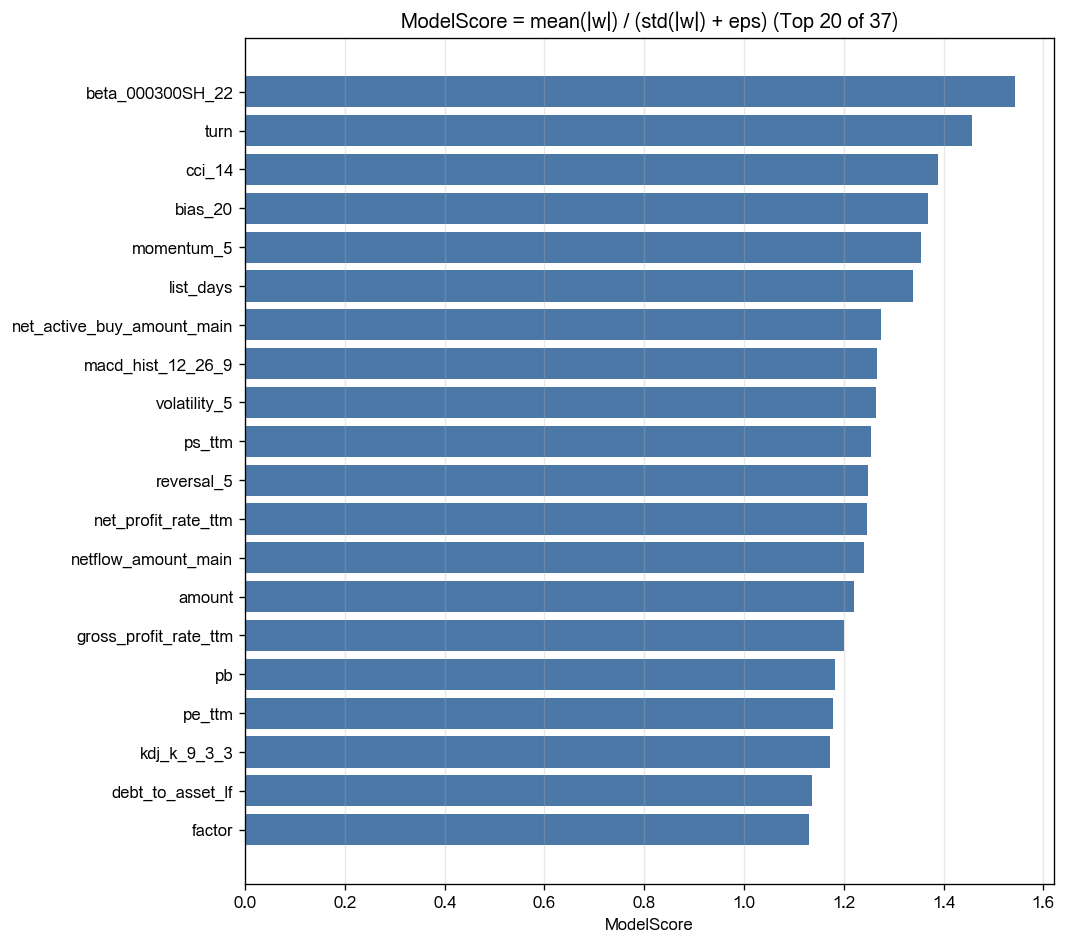
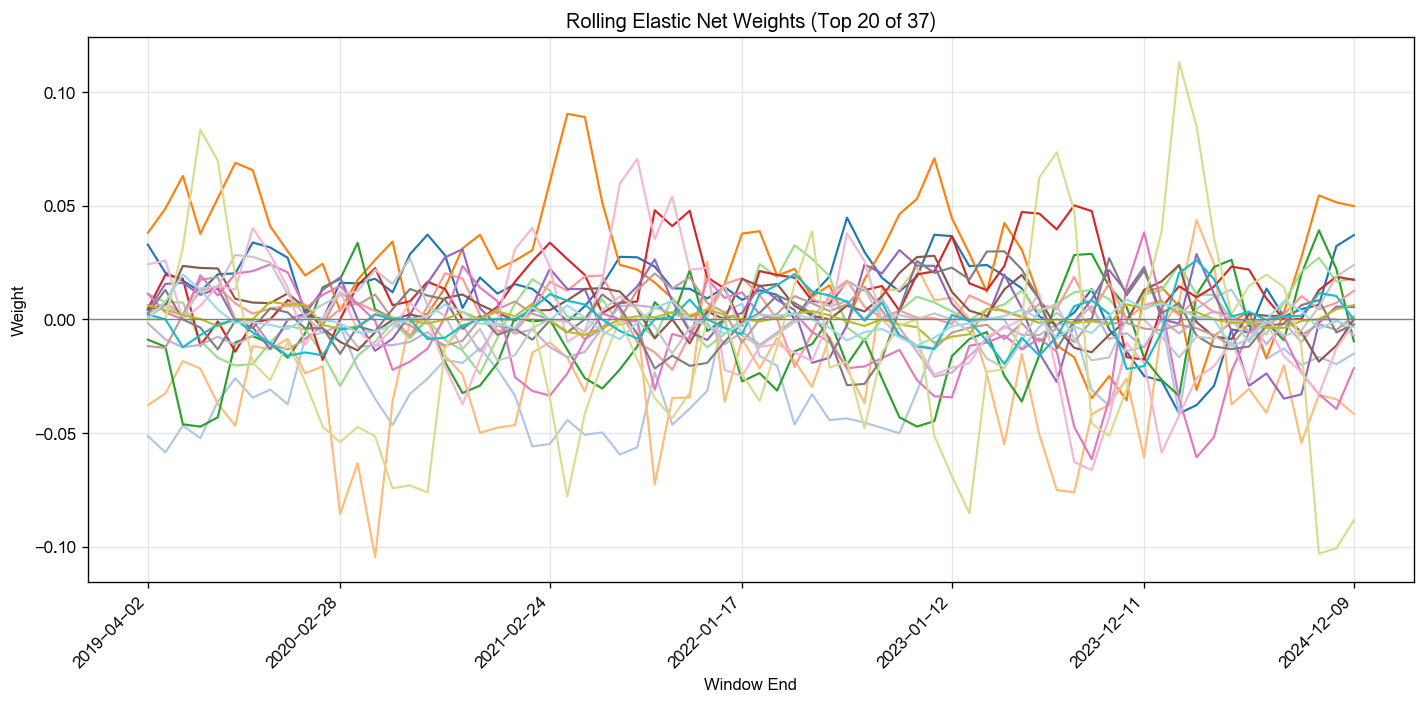
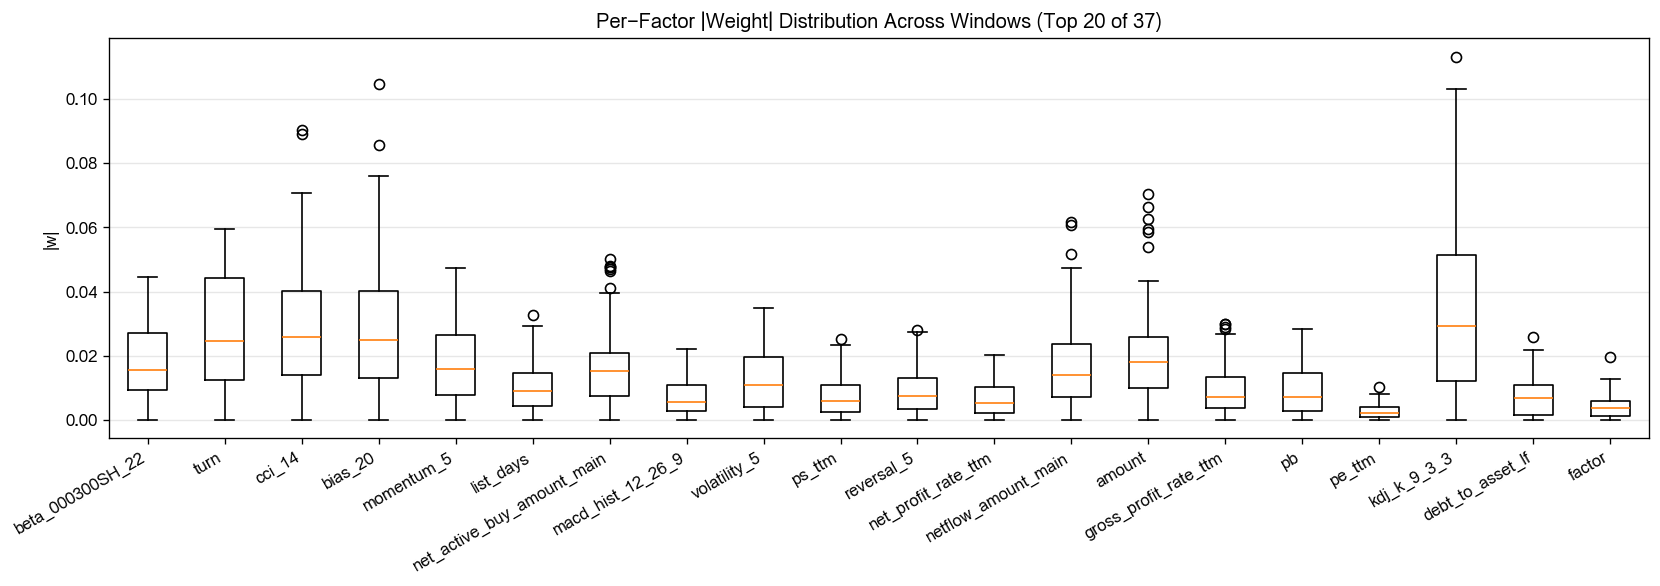
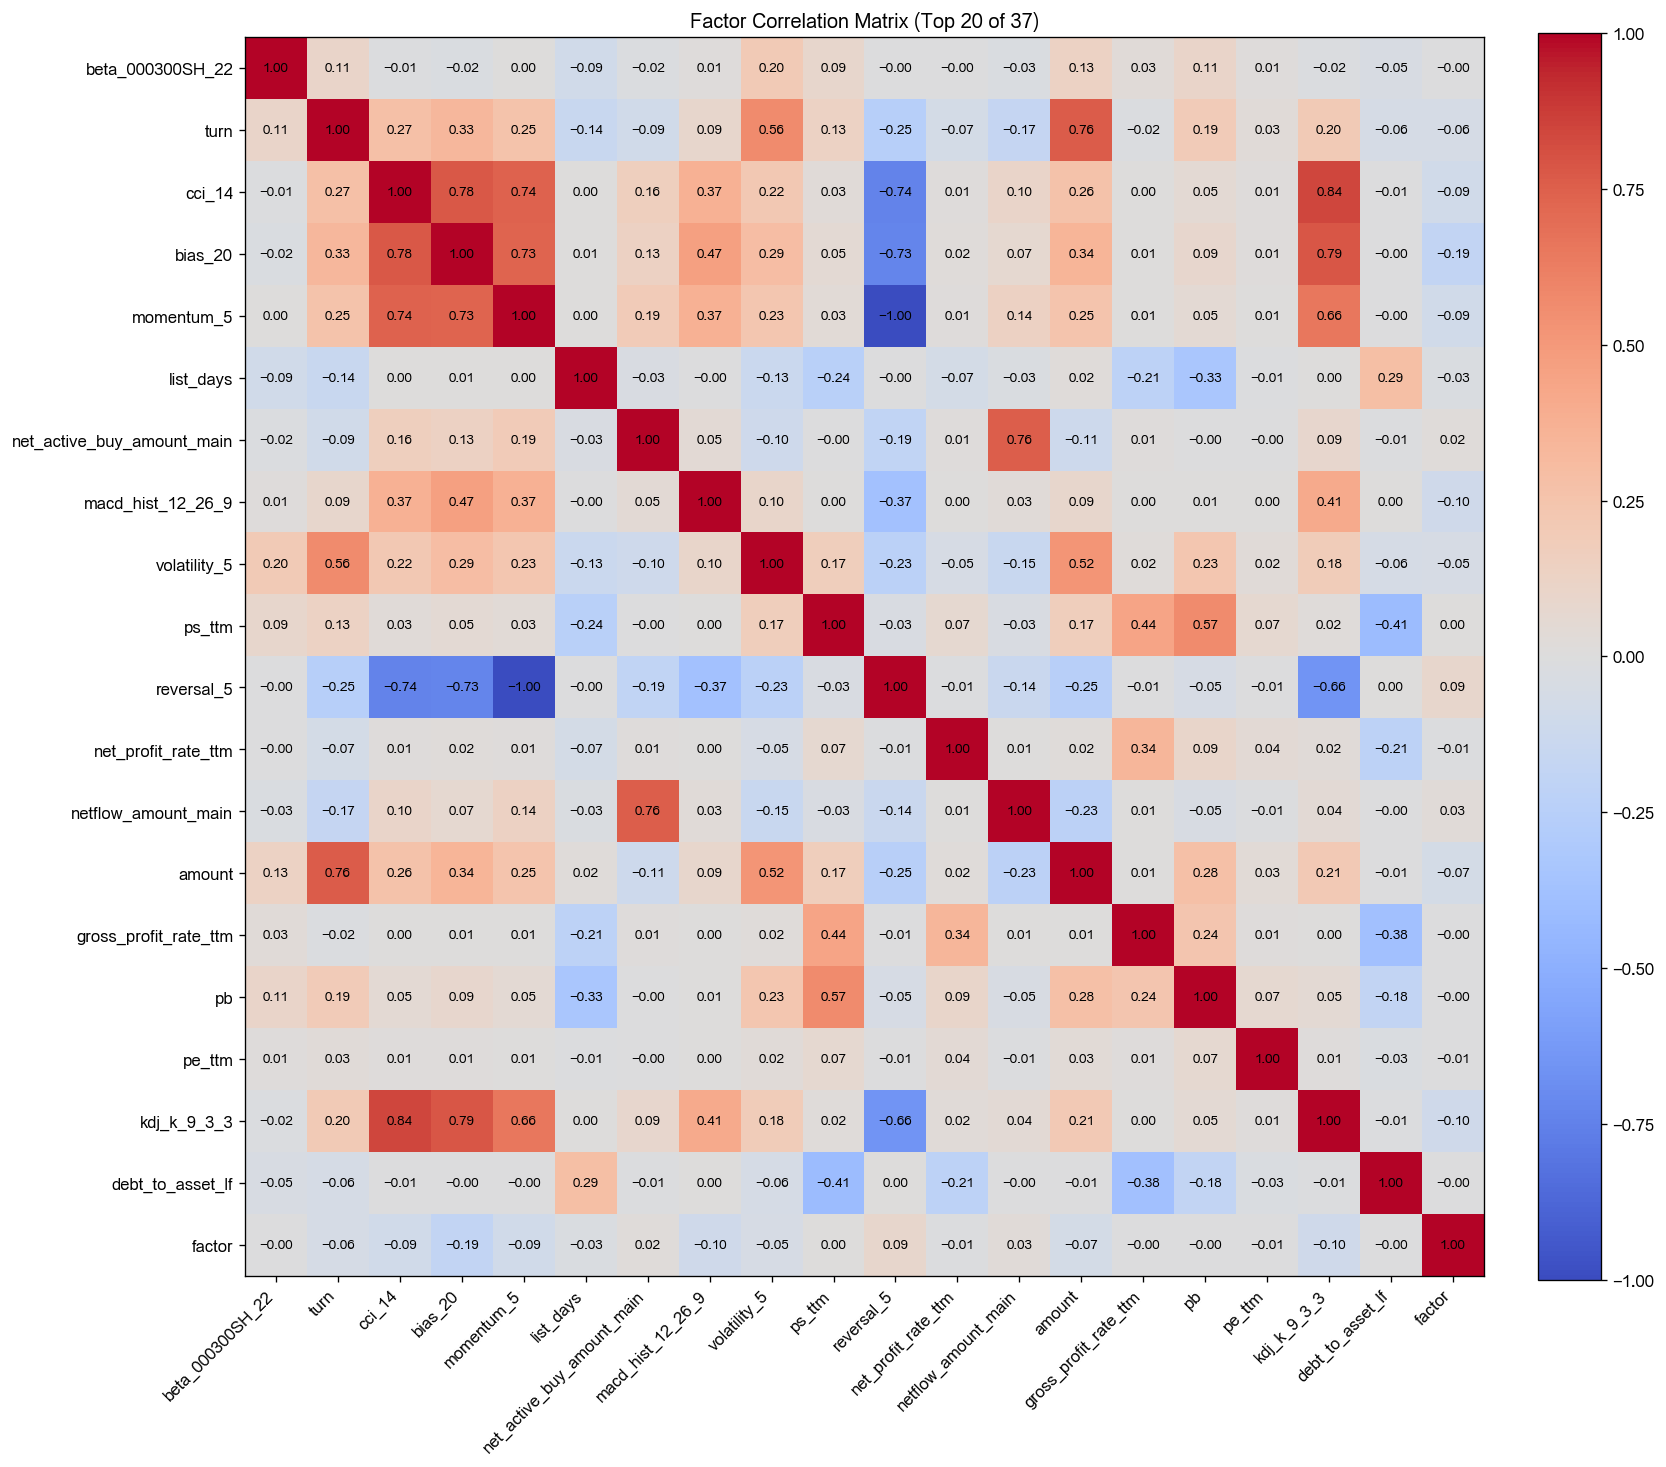

[2026-07-10 11:08:49] [warning  ] 返回的Outputs实例(size=218418116) 大于 64K, 将不会被缓存
[2026-07-10 11:08:49] [info     ] bigalpha_eval.v4 运行完成 [147.579s].


In [2]:
def main(datasources, start_date, end_date):
    """
    因子 a25 (fid=133): TsSkew($turnover, 50.0)
    原始 IC(7d) = -0.02567, Sharpe(7d) = +4.693
    严格按 DSL 1:1 实现: 窗口 50, Neg=False
    v2 严格版: SQL 加 'as' alias, 不加反引号, 嵌套算子完整实现
    """
    import pandas as pd
    import numpy as np
    import dai

    bar1m = datasources["bar1m"]
    LOOKBACK_DAYS = 70  # 严格按 DSL 窗口 50 + 缓冲
    query_start_date = pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)

    WIN = 50  # 严格按 DSL 数字, 不缩窗口

    sql = f"""
    -- 严格按 DSL 1:1 实现, 窗口大小 50
    -- DSL: TsSkew($turnover, 50.0)
    WITH cte_min AS (
        SELECT
            strftime(date_trunc('day', date), '%Y-%m-%d') as trading_day, instrument,
    SUM(amount) / NULLIF(SUM(volume), 0) as turnover,
    SUM(volume) as volume,
    SUM(amount) as amount,
    AVG(close) as close,

    AVG(bid_price1) as bid_price1,
    AVG(ask_price1) as ask_price1,
    SUM(deal_number) as deal_number
        FROM {bar1m}
        WHERE ask_price1 > 0 AND bid_price1 > 0
        GROUP BY date_trunc('day', date), instrument
    )
    SELECT
        trading_day, instrument,
        AVG(volume) as volume,
        AVG(amount) as amount,
        AVG(close) as close,
        AVG(turnover) as turnover,
        AVG(bid_price1) as bid_price1,
        AVG(ask_price1) as ask_price1,
        AVG(deal_number) as deal_number,
        CAST(0.0 AS DOUBLE) as weighted_imbalance
    FROM cte_min
    GROUP BY instrument, trading_day
    
    """

    df = dai.query(sql, filters={'date': [query_start_date, end_date]}, compression=True).df()
    for col in df.columns:
        if col not in ('trading_day', 'instrument', 'date'):
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df['date'] = pd.to_datetime(df['trading_day']).dt.normalize()
    df = df.sort_values(['instrument', 'date']).reset_index(drop=True)

    # ===== 严格按 DSL 实现 (完整嵌套): TsSkew($turnover, 50.0) =====
    df['factor_raw'] = df['turnover'].rolling(50, min_periods=25).skew()

    # IC(7d)=-0.02567 < 0, × -1 翻向
    df['factor'] = -df['factor_raw']

    # 截断到评估区间
    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    df = df[(df['date'] >= sd) & (df['date'] <= ed)].reset_index(drop=True)
    df = df[['date', 'instrument', 'factor']].dropna(subset=['factor']).reset_index(drop=True)
    df['factor'] = df['factor'].replace([float('inf'), float('-inf')], pd.NA)
    df = df.dropna(subset=['factor'])

    # 对齐股票池
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date']).dt.normalize()
    df['date'] = df['date'].dt.normalize()
    df = pd.merge(df, stk_pool, how='inner', on=['date', 'instrument'])

    return df[['date', 'instrument', 'factor']]

if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2019-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
